In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('RTA Dataset.csv')

# Primeras miradas
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('RTA Dataset.csv')

# 1. Para columnas con MUCHOS nulos (>30%), las dejamos pero las marcamos
cols_muchos_nulos = ['Defect_of_vehicle', 'Service_year_of_vehicle']

# 2. Para columnas categóricas con pocos nulos → rellenar con la MODA
cols_pocos_nulos = [
    'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
    'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Type_of_collision', 'Vehicle_movement'
]

for col in cols_pocos_nulos:
    moda = df[col].mode()[0]
    df[col].fillna(moda, inplace=True)

# 3. Verificar que quedó limpio
print("Nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDataset listo: {df.shape[0]} filas, {df.shape[1]} columnas")

Nulos restantes:
Service_year_of_vehicle    3928
Defect_of_vehicle          4427
Work_of_casuality          3198
Fitness_of_casuality       2635
dtype: int64

Dataset listo: 12316 filas, 32 columnas


C:\Users\DELL\AppData\Local\Temp\ipykernel_7076\3552473935.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(moda, inplace=True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_7076\2256029436.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


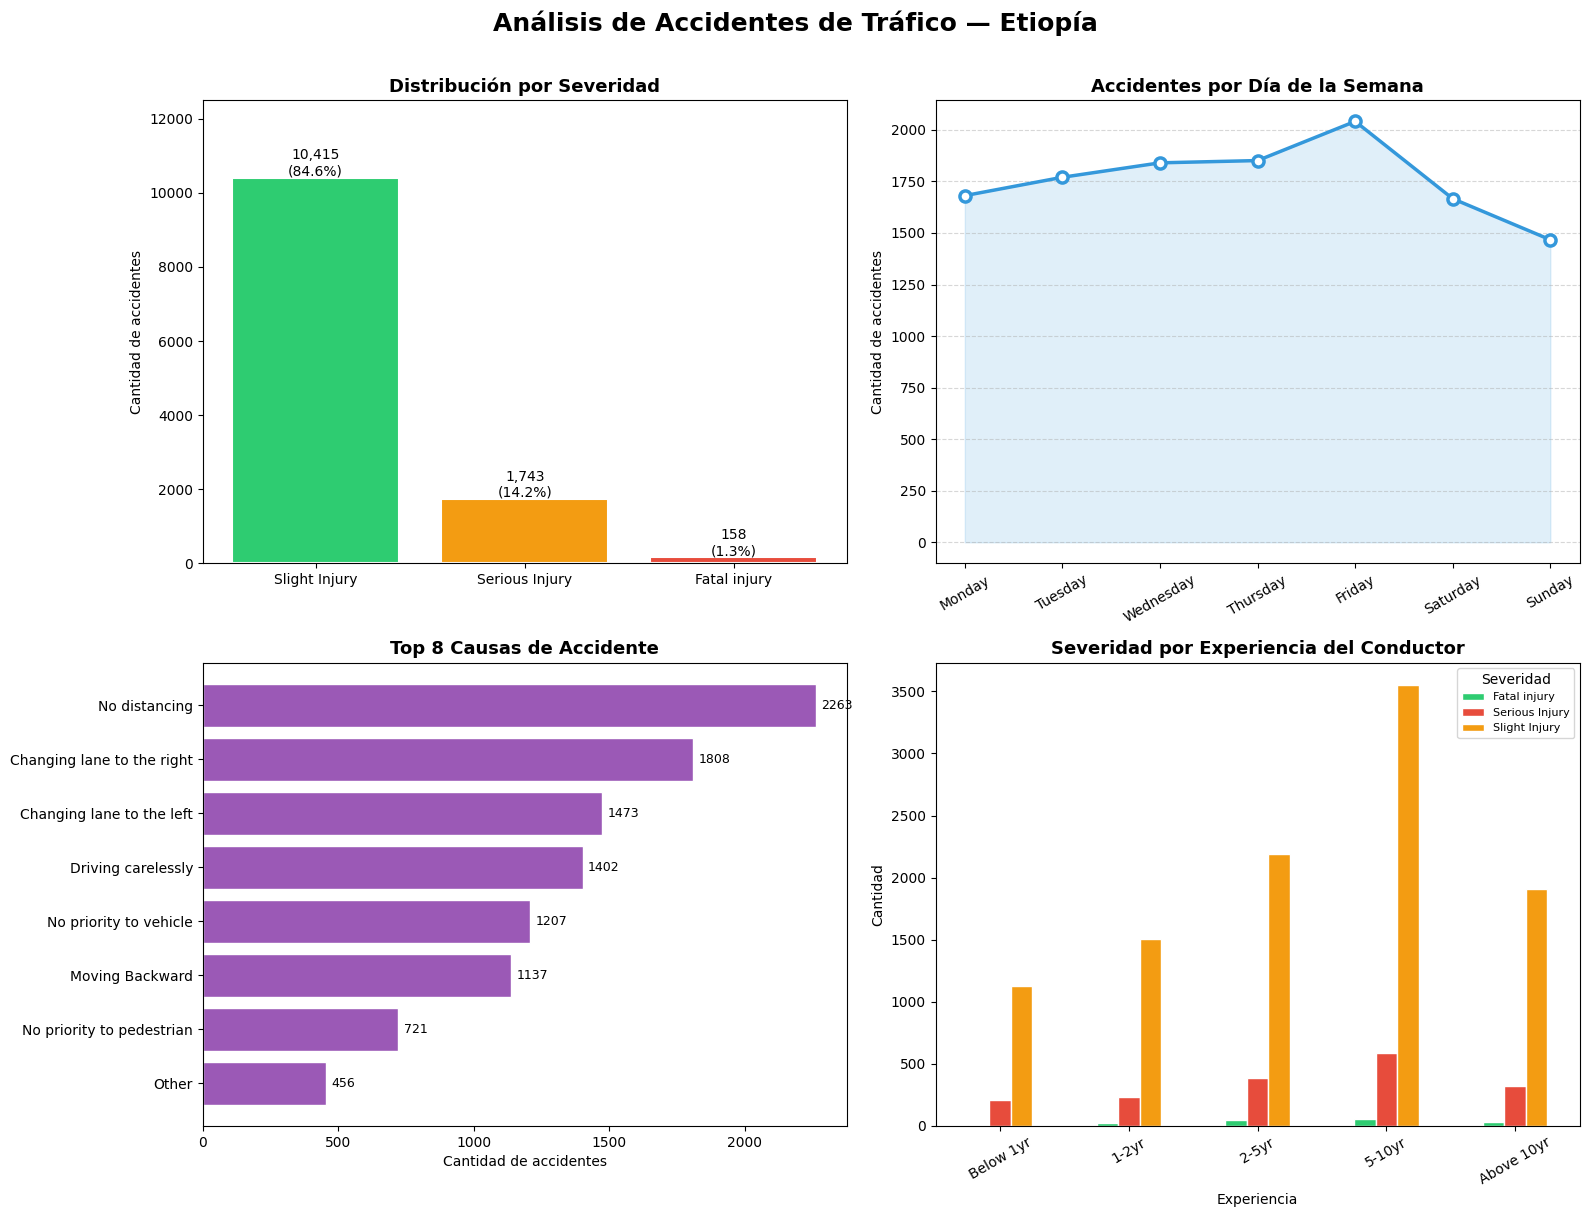

✅ Gráfico guardado como 'analisis_accidentes.png'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('RTA Dataset.csv')

# Limpieza previa
cols_pocos_nulos = [
    'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
    'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Type_of_collision', 'Vehicle_movement'
]
for col in cols_pocos_nulos:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ---- FIGURA PRINCIPAL ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Accidentes de Tráfico — Etiopía', fontsize=18, fontweight='bold', y=1.01)

# 1. Severidad de accidentes
ax1 = axes[0, 0]
severity_counts = df['Accident_severity'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(severity_counts.index, severity_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Distribución por Severidad', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Cantidad de accidentes')
for bar, val in zip(bars, severity_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, severity_counts.max() * 1.2)

# 2. Accidentes por día de la semana
ax2 = axes[0, 1]
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['Day_of_week'].value_counts().reindex(orden_dias)
ax2.plot(orden_dias, day_counts.values, marker='o', color='#3498db',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax2.fill_between(orden_dias, day_counts.values, alpha=0.15, color='#3498db')
ax2.set_title('Accidentes por Día de la Semana', fontsize=13, fontweight='bold')
ax2.set_ylabel('Cantidad de accidentes')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Top 8 causas de accidente
ax3 = axes[1, 0]
top_causas = df['Cause_of_accident'].value_counts().head(8)
ax3.barh(top_causas.index[::-1], top_causas.values[::-1], color='#9b59b6', edgecolor='white')
ax3.set_title('Top 8 Causas de Accidente', fontsize=13, fontweight='bold')
ax3.set_xlabel('Cantidad de accidentes')
for i, (val, idx) in enumerate(zip(top_causas.values[::-1], top_causas.index[::-1])):
    ax3.text(val + 20, i, str(val), va='center', fontsize=9)

# 4. Severidad por experiencia del conductor
ax4 = axes[1, 1]
exp_sev = df.groupby(['Driving_experience', 'Accident_severity']).size().unstack(fill_value=0)
exp_order = ['Below 1yr', '1-2yr', '2-5yr', '5-10yr', 'Above 10yr']
exp_sev = exp_sev.reindex([e for e in exp_order if e in exp_sev.index])
exp_sev.plot(kind='bar', ax=ax4, color=['#2ecc71', '#e74c3c', '#f39c12'],
             edgecolor='white', linewidth=1)
ax4.set_title('Severidad por Experiencia del Conductor', fontsize=13, fontweight='bold')
ax4.set_xlabel('Experiencia')
ax4.set_ylabel('Cantidad')
ax4.tick_params(axis='x', rotation=30)
ax4.legend(title='Severidad', fontsize=8)

plt.tight_layout()
plt.savefig('analisis_accidentes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como 'analisis_accidentes.png'")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('RTA Dataset.csv')

# ¿Los viernes tienen accidentes MÁS GRAVES o solo más cantidad?
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = df.groupby(['Day_of_week', 'Accident_severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(orden_dias)

# Calcular % de accidentes fatales por día
pivot['%_Fatal'] = (pivot['Fatal injury'] / pivot.sum(axis=1) * 100).round(2)
pivot['%_Serious'] = (pivot['Serious Injury'] / pivot.sum(axis=1) * 100).round(2)

print(pivot[['Fatal injury', 'Serious Injury', 'Slight Injury', '%_Fatal', '%_Serious']])

Accident_severity  Fatal injury  Serious Injury  Slight Injury  %_Fatal  \
Day_of_week                                                               
Monday                       12             204           1465     0.71   
Tuesday                      17             257           1496     0.96   
Wednesday                    19             262           1559     1.03   
Thursday                     22             272           1557     1.19   
Friday                       16             313           1712     0.78   
Saturday                     37             245           1384     2.22   
Sunday                       35             190           1242     2.39   

Accident_severity  %_Serious  
Day_of_week                   
Monday                 12.13  
Tuesday                14.51  
Wednesday              14.23  
Thursday               14.69  
Friday                 15.33  
Saturday               14.69  
Sunday                 12.93  


In [3]:
from scipy import stats

# Comparar accidentes fatales: Lunes vs Domingo
lunes = df[df['Day_of_week'] == 'Monday']['Accident_severity']
domingo = df[df['Day_of_week'] == 'Sunday']['Accident_severity']

# Convertir a binario: 1 = Fatal, 0 = No fatal
lunes_fatal = (lunes == 'Fatal injury').astype(int)
domingo_fatal = (domingo == 'Fatal injury').astype(int)

# Chi-square test
tabla = pd.crosstab(
    df[df['Day_of_week'].isin(['Monday', 'Sunday'])]['Day_of_week'],
    df[df['Day_of_week'].isin(['Monday', 'Sunday'])]['Accident_severity']
)

chi2, p_value, dof, expected = stats.chi2_contingency(tabla)

print(f"Chi2: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\n{'✅ Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA' if p_value < 0.05 else '❌ Diferencia no significativa'}")
print(f"{'→ NO es casualidad, es un patrón real.' if p_value < 0.05 else '→ Podría ser ruido estadístico.'}")

Chi2: 15.6480
P-value: 0.0004

✅ Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA
→ NO es casualidad, es un patrón real.
